**When to use SRHT / Hadamard Rademacher Sketching instead of Uniform Sampling**

In [1]:
from IPython.display import Markdown
Markdown('![Image Description](./SRHT_Intuition.png)')

![Image Description](./SRHT_Intuition.png)

In [2]:
# Import all the needed packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cho_factor, cho_solve
import torch
import spyrit.core.torch as st

**STEP 1: Simulation**

In [3]:
def simulate_matrix(n, d, no_components, rho, abs_bound_X):
    """
    Simulate matrices X, Y, beta, and epsilon with properties favoring SRHT and Hadamard Randomized Sampling
    over uniform sampling. The matrix X will have high-leverage rows in a tiny part, strong correlations
    among groups of rows, and structured sparsity for uneven leverage distribution.

    Parameters:
    - n: Number of rows (total samples)
    - d: Number of columns (features)
    - no_components: Number of multivariate Gaussian components in X (must be 2 or error_raised)
    - rho: Autocorrelation coefficient for the error term and correlation strength in covariance
    - abs_bound_X: Absolute bound for X to set elements to 0, creating sparsity

    Returns:
    - X: Simulated feature matrix
    - Y: Simulated response matrix
    - beta: Simulated coefficient vector
    - epsilon: Simulated error term with autocorrelation
    """
    ### Form the X matrix
    X = np.zeros((0, d))
    
    # Define component sizes and means for high-leverage rows and uneven distribution
    def generate_components(n, no_components):
        if no_components == 2:
            alpha = 0.999
            component = [n - 1,1]  # alpha, 1-alpha
            mean = [1, 1000]  # Large mean for tiny component
        else:
            raise ValueError("Invalid number of components")
        
        # Adjust the last component to ensure the sum equals n
        component[-1] = n - sum(component[:-1])
        return component, mean
    
    num_list, mean_list = generate_components(n, no_components)
    
    # Generate covariance matrix with strong correlations
    def generate_correlation_matrix(d, rho):
        S = rho * np.ones((d, d)) + (1 - rho) * np.eye(d)  # Correlation rho off-diagonal, 1 on diagonal
        return S
    
    cov = generate_correlation_matrix(d, rho)
    
    # Generate multivariate Gaussian components
    for i in range(no_components):
        mean_value = mean_list[i]
        # Sparse mean vector with high probability of non-zero entries
        mean_vector = mean_value * np.random.binomial(1, 0.9, size=d)
        X_ = np.random.multivariate_normal(mean_vector, cov, num_list[i])
        X = np.vstack((X, X_))
    
        # Apply sparsity threshold for structured sparsity
        if i == no_components - 1:
            X[abs(X) < abs_bound_X] = 0
    X = np.array(X)
    ### Form the fixed beta
    beta_value = np.random.binomial(1, 0.9, size=d)
    beta = (beta_value * np.random.uniform(-1, 1, size=d)).reshape(-1, 1)
    
    ### Form the error term - epsilon, with autocorrelation
    r = rho  # Use same rho for consistency
    epsilon_matrix = np.zeros((0, 1))
    for i in range(no_components):
        epsilon = np.zeros((num_list[i], 1))
        epsilon[0] = np.random.normal(0, 1)
        for t in range(1, num_list[i]):
            epsilon[t] = r * epsilon[t-1] + np.random.normal(0, 1)
        epsilon_matrix = np.vstack((epsilon_matrix, epsilon))
    epsilon = epsilon_matrix
    
    ### Form the Y matrix
    Y = X @ beta + epsilon
    
    return X, Y, beta, epsilon

# Example usage (unchanged from your notebook)
n = 8192  # number of rows
d = 200   # number of columns
no_components = 2  # number of components
rho = 0.8  # autocorrelation and correlation strength
abs_bound_X = 0.1  # sparsity threshold
X, Y, beta, epsilon = simulate_matrix(n, d, no_components, rho, abs_bound_X)

**Step 2: Singular Value Decomposition (SVD)**<br>
*To show the sparsity and not even distribution*

*U_1 Vector: First column of U: variation of values for analysis*

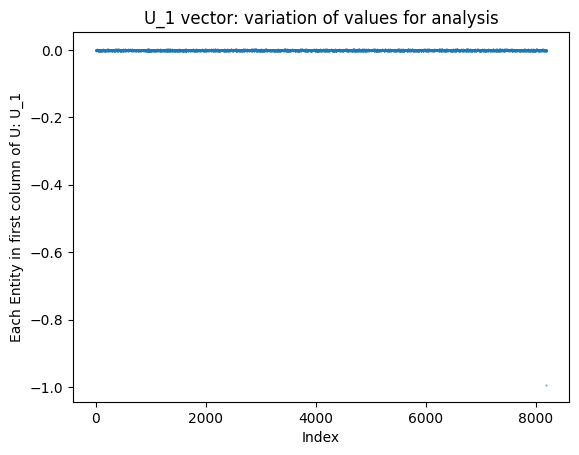

In [4]:
import matplotlib.pyplot as plt

# Compute the singular decomposition of matrix X, X = (U)(Σ)(V^T)
U, s, Vh = np.linalg.svd(X)
# U_1 is the first column of matrix U, which represents the principal direction of variation in X
U_1 = U[:, 0]

# Plot singular values using a dot plot
plt.scatter(range(len(U_1)), U_1,s = 0.1)
plt.xlabel('Index')
plt.ylabel('Each Entity in first column of U: U_1')
plt.title('U_1 vector: variation of values for analysis')
plt.show()

**Step 4: Define functions for calculating error ratio and norms**

In [5]:
def solution_error(x_hat, beta_true):
    return np.linalg.norm(x_hat - beta_true)**2
def calculate_the_norm_square(A, b, x_selected):
    A = np.array(A)
    x_selected = np.array(x_selected)
    return np.sum((np.dot(A, x_selected) - b) ** 2)
def error_ratio(A,b,x_hat_bar,x_star):
    return (calculate_the_norm_square(A,b,x_hat_bar) - calculate_the_norm_square(A,b,x_star)) / calculate_the_norm_square(A,b,x_star)

**Step 5: Solve for X_star**<br>
*Use cholesky decomposition for solving X_star*

In [6]:
def solver(A, b):
    A = np.array(A)
    b = np.array(b)
    x_star, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    return x_star

x_star = solver(X, Y)

**STEP 6: Uniform Sampling Sampling // Algorithm 1: Distributed Randomized Regression**

In [7]:
# e.g. our desired sketching size is
m = 100
# Algorithm 1 inserting inside uniform sampling: Distributed Randomized Regression

# S_k @ A here is just computed as A [uniformly_sampled_index]
# As S_k here is just a diagnoal matrix of 1 or 0 where sampled rows have 1 as value
def uniform_sampling_1(X,Y,n,m,q):
    X = np.array(X)
    Y = np.array(Y)
    x_hat_list = []
    for k in range(q):
        index = np.random.choice(n, size=m, replace=False)
        X_sk = X[index]
        Y_sk = Y[index]
        x_hat = solver(X_sk,Y_sk)
        x_hat_list.append(x_hat)
    x_bar = sum(x_hat_list) / q
    return x_bar

**Step 7: Hadamard Randomized Sampling // Algorithm 1: Distributed Randomized Regression**<br>

In [8]:
# Algorithm 1 inserting inside hadamard rademacher randomization: Distributed Randomized Regression

# Step 1: Hadamard rademacher randomization
def fhm(X,Y):
    # Generate a diagonal matrix of -1 or 1 with 0.5 probability
    diag_matrix = np.diag(np.random.choice([-1, 1], size=X.shape[0]))
    signs = diag_matrix
    # Multiply each row of X and Y by the corresponding sign
    result_X = np.dot(signs, X)
    result_Y = np.dot(signs, Y)
    # Convert to PyTorch tensor with float64
    tensor_matrix_X = torch.tensor(result_X, dtype=torch.float64)
    tensor_matrix_Y = torch.tensor(result_Y, dtype=torch.float64)
    # Apply FWHT
    tensor_matrix_X = st.fwht(tensor_matrix_X.T).T
    tensor_matrix_Y = st.fwht(tensor_matrix_Y)
    # Convert back to numpy array
    X = tensor_matrix_X.numpy()
    Y = tensor_matrix_Y.numpy()
    return X, Y

# Step 2: Uniform sampling on the Hadamard transformed X
def Hadamard_Randomized_Sampling_1(X, Y, n, m, q):
    X = np.array(X)
    Y = np.array(Y)
    X, Y = fhm(X, Y)
    x_hat_list = []
    for k in range(q):
        index = np.random.choice(n, size=m, replace=False)
        X_sk = X[index] / np.sqrt(m)
        Y_sk = Y[index] / np.sqrt(m)
        X_sk = np.array(X_sk)
        Y_sk = np.array(Y_sk)
        x_hat = solver(X_sk,Y_sk)
        x_hat_list.append(x_hat)
    x_bar = sum(x_hat_list) / q
    return x_bar

**Step 8: Subsampled Randomized Hadamard Transforom // Algorithm 1: Distributed Randomized Regression**<br>

In [9]:
def Subsampled_Randomized_Hadamard_Transform_1(X, Y, n, m, q):
    # Convert inputs to numpy arrays
    X = np.array(X)
    Y = np.array(Y)
    
    # Store copies of the original X and Y
    X_orig = X.copy()
    Y_orig = Y.copy()
    
    x_hat_list = []
    for k in range(q):
        # Apply fhm to the original X and Y, not the transformed versions
        X_transformed, Y_transformed = fhm(X_orig, Y_orig)
        
        # Subsample m rows from the transformed matrices
        index = np.random.choice(n, size=m, replace=False)
        X_sk = X_transformed[index] / np.sqrt(m)
        Y_sk = Y_transformed[index] / np.sqrt(m)
        
        # Ensure subsampled matrices are numpy arrays
        X_sk = np.array(X_sk)
        Y_sk = np.array(Y_sk)
        
        # Solve the smaller problem
        x_hat = solver(X_sk, Y_sk)
        x_hat_list.append(x_hat)
    
    # Average the solutions
    x_bar = sum(x_hat_list) / q
    return x_bar

**Step 9: Final Error Ratio plot for comparison of these three methods**<br>
*Note that in the Uniform Sampling there is two version: With padding or Without padding of matrices X and Y*<br>

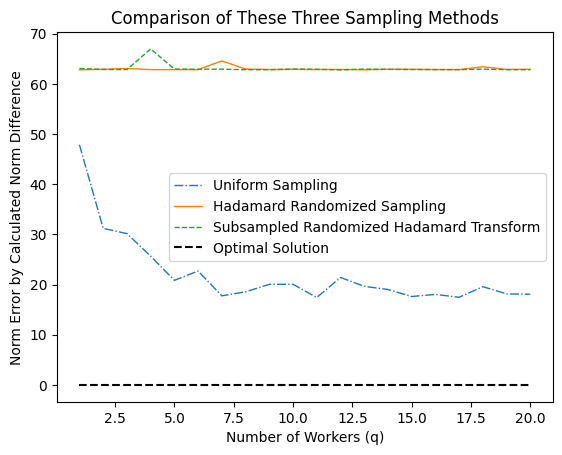

In [10]:
error_uniform = []
error_hadamard_rand = []
error_SRHT = []
error_star = np.zeros((20,1))

# Calculate the error rate for each method
for q in range(1, 21):  # adjust the range as needed
    x_bar_uniform = uniform_sampling_1(X,Y,X.shape[0],m,q)
    x_bar_hadamard_rand = Hadamard_Randomized_Sampling_1(X,Y,X.shape[0],m,q)
    x_bar_SRHT = Subsampled_Randomized_Hadamard_Transform_1(X,Y,X.shape[0],m,q)
    error_uniform.append(solution_error(x_bar_uniform,x_star))
    error_hadamard_rand.append(solution_error(x_bar_hadamard_rand,x_star))
    error_SRHT.append(solution_error(x_bar_SRHT,x_star))

# Create the plot
plt.plot(range(1, 21), error_uniform, label='Uniform Sampling',linestyle = '-.',linewidth = 1)
plt.plot(range(1, 21), error_hadamard_rand, label='Hadamard Randomized Sampling',linestyle = '-',linewidth = 1)
plt.plot(range(1, 21), error_SRHT, label='Subsampled Randomized Hadamard Transform',linestyle = '--',linewidth = 1)
plt.plot(range(1, 21), error_star, label='Optimal Solution', linestyle='--',color = 'black')

# Add labels and title
plt.xlabel('Number of Workers (q)')
plt.ylabel('Norm Error by Calculated Norm Difference')
plt.title('Comparison of These Three Sampling Methods')
plt.legend()
plt.show()